# 1. Question Embeddings And Decomposition

В этом notebook мы исследуем, как разложить вопрос Polymarket на две части:

- **semantic core**: суть события;
- **parameterization**: время, дедлайны, числа, пороги и другие числовые модификаторы.

Это нужно для идеи masked market reconstruction: если вопросы отличаются только параметром вроде `7 days` vs `30 days`, модель должна видеть, что это одна semantic family, но разные parameterizations.

## Импорты и конфигурация

Здесь мы используем уже существующие data layers: raw parquet snapshot и canonical layer.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from polymarket_research import PolymarketDataset
from polymarket_research.data.canonical import CanonicalDataset, CanonicalDatasetBuilder
from polymarket_research.utils.text import normalize_text, parse_listish, tag_jaccard

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 160)

REPO_ROOT = Path('/Users/sneddy/research/polymarket_research')
RAW_CACHE_DIR = REPO_ROOT / 'research_notebooks' / 'running_artefacts'
CANONICAL_CACHE_DIR = RAW_CACHE_DIR / 'canonical_dataset'
TOP_K = 5
RANDOM_STATE = 42


## Загружаем raw и canonical layers

Сначала поднимаем raw snapshot из parquet. Затем пытаемся загрузить уже сохранённый canonical cache; если его ещё нет, строим canonical dataset c `resolved_only=True` и сразу сохраняем его. Это даёт нам стабильную рабочую выборку без future markets.

In [2]:
raw_dataset = PolymarketDataset.from_parquet(RAW_CACHE_DIR)

if (CANONICAL_CACHE_DIR / 'markets.parquet').exists() and (CANONICAL_CACHE_DIR / 'probabilities.parquet').exists():
    canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
    canonical_source_label = f'canonical cache: {CANONICAL_CACHE_DIR}'
else:
    canonical = CanonicalDatasetBuilder(raw_dataset=raw_dataset, resolved_only=True).build()
    canonical.save(CANONICAL_CACHE_DIR)
    canonical_source_label = f'built and saved: {CANONICAL_CACHE_DIR}'

markets = canonical.markets.copy()
probabilities = canonical.probabilities.copy()

print('Canonical source:', canonical_source_label)
display(raw_dataset.summary())
display(canonical.summary())
display(markets[['market_id', 'question', 'primary_domain', 'family_id']].head())

Canonical source: canonical cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts/canonical_dataset


,name,loaded,rows,cols
0,markets,True,2905,21
1,probabilities,True,50918460,7


,name,rows,cols
0,markets,2781,23
1,probabilities,48329908,7
2,external_covariates,263808,19


,market_id,question,primary_domain,family_id
0,546814,Will Zelenskyy wear a suit before July?,politics,politics::celebrities::zelenskyy wear suit before july
1,680392,US government shutdown Saturday?,politics,politics::congress|gov shutdown|parent for derivative::us government shutdown saturday
2,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,politics,politics::macro election 2|mayoral elections|nyc mayor::zohran mamdani win 2025 nyc mayoral
3,529278,Will Frances Fitzgerald win the Irish Presidential Election?,politics,politics::elections|global elections|ireland::frances fitzgerald win irish presidential election
4,519075,Will Hunor Kelemen win the Romanian presidential election?,politics,politics::global elections|politics|romania::hunor kelemen win romanian presidential election


## Строим decomposition question -> semantic core + parameterization

Нам нужна не одна строка вопроса, а две осмысленные части. В первом приближении сделаем это эвристически:

- извлечём numeric/date/time spans как parameterization;
- удалим их из текста и получим semantic core.

Это не финальная модель, а исследовательская декомпозиция, которая поможет понять, насколько такие различия реально встречаются в данных.

In [3]:
MONTHS = 'january february march april may june july august september october november december'.split()
MONTH_PATTERN = r'\b(?:' + '|'.join(MONTHS) + r')\s+\d{1,2}(?:\s+\d{4})?\b'
NUMBER_UNIT_PATTERN = r'\b\d+(?:\.\d+)?\s*(?:day|days|week|weeks|month|months|year|years|hour|hours|minute|minutes|pct|percent|points|seats|votes|terms)\b'
YEAR_PATTERN = r'\b20\d{2}\b'
PERCENT_PATTERN = r'\b\d+(?:\.\d+)?\s*%\b'
STANDALONE_NUMBER_PATTERN = r'\b\d+(?:\.\d+)?\b'
PARAMETER_GLUE_TOKENS = {'within', 'before', 'after', 'by', 'until', 'through', 'over', 'under', 'at', 'least', 'most'}

def extract_parameter_spans(question: str) -> list[str]:
    """Extract numeric and temporal spans from a normalized market question."""
    text = normalize_text(question)
    matches = []
    for pattern in [MONTH_PATTERN, NUMBER_UNIT_PATTERN, PERCENT_PATTERN, YEAR_PATTERN, STANDALONE_NUMBER_PATTERN]:
        matches.extend(match.group(0).strip() for match in re.finditer(pattern, text))
    deduped = []
    seen = set()
    for item in matches:
        if item not in seen:
            deduped.append(item)
            seen.add(item)
    return deduped

def extract_parameter_types(question: str) -> str:
    """Map extracted numeric spans into coarse parameter types."""
    spans = extract_parameter_spans(question)
    kinds = []
    for span in spans:
        if any(month in span for month in MONTHS) or re.fullmatch(YEAR_PATTERN, span):
            kinds.append('date')
        elif any(unit in span for unit in ['day', 'week', 'month', 'year', 'hour', 'minute']):
            kinds.append('time_window')
        elif '%' in span or 'percent' in span or 'pct' in span:
            kinds.append('percentage')
        else:
            kinds.append('number')
    if not kinds:
        return '<none>'
    return '|'.join(sorted(dict.fromkeys(kinds)))

def build_parameter_signature(question: str) -> str:
    """Build a compact string that summarizes extracted parameter spans."""
    spans = extract_parameter_spans(question)
    return ' | '.join(spans) if spans else '<none>'

def build_semantic_core(question: str) -> str:
    """Strip numeric and temporal modifiers to expose the event-level semantic core."""
    text = normalize_text(question)
    for pattern in [MONTH_PATTERN, NUMBER_UNIT_PATTERN, PERCENT_PATTERN, YEAR_PATTERN, STANDALONE_NUMBER_PATTERN]:
        text = re.sub(pattern, ' ', text)
    tokens = [token for token in text.split() if token not in PARAMETER_GLUE_TOKENS]
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text or normalize_text(question)


## Добавляем decomposition в market table

Теперь можно увидеть, как одна и та же semantic family распадается на разные parameterizations.

In [4]:
markets['question_norm'] = markets['question'].map(normalize_text)
markets['semantic_core'] = markets['question'].map(build_semantic_core)
markets['parameter_signature'] = markets['question'].map(build_parameter_signature)
markets['parameter_types'] = markets['question'].map(extract_parameter_types)
markets['tag_count'] = markets['tag_labels'].map(lambda value: len(parse_listish(value)))

display(markets[['question', 'semantic_core', 'parameter_signature', 'parameter_types']].sample(12, random_state=RANDOM_STATE))

,question,semantic_core,parameter_signature,parameter_types
1561,Will Bianca Censori be the #1 searched person on Google this year?,will bianca censori be the searched person on google this year,1,number
1099,Israel military action against Iran in July?,israel military action against iran in july,<none>,<none>
1455,Will Israel declare war on Iran by Friday?,will israel declare war on iran friday,<none>,<none>
911,"US strikes Iran by February 15, 2026?",us strikes iran,february 15 2026 | 2026 | 15,date|number
521,Will the New Democratic Party win the most seats in New Brunswick in the next Canadian Election?,will the new democratic party win the seats in new brunswick in the next canadian election,<none>,<none>
1537,Will Carlos Sainz Jr. be the 2025 Drivers Champion?,will carlos sainz jr be the drivers champion,2025,date
1452,Will Russia capture all of Pokrovsk by March 31?,will russia capture all of pokrovsk,march 31 | 31,date|number
2492,Will Gold close between $3300 and $3400 at the end of 2025?,will gold close between and the end of,2025 | 3300 | 3400,date|number
2683,Bank of Japan increases interest rates by 25 bps after October 2025 meeting?,bank of japan increases interest rates bps october meeting,2025 | 25,date|number
1637,Will Ismail Haniyeh be ranked #1 globally in Google’s Year in Search 2025 Passings?,will ismail haniyeh be ranked globally in google s year in search passings,2025 | 1,date|number


## Насколько часто встречаются parameterized families

Эта таблица нужна, чтобы понять, есть ли в данных реальные группы вида `same semantic core, different parameterization`. Если таких групп почти нет, идея decomposition будет слабее; если их много, это сильный сигнал в пользу идеи `6`.

In [5]:
core_stats = (
    markets.groupby('semantic_core', as_index=False)
    .agg(
        market_count=('market_id', 'nunique'),
        parameter_count=('parameter_signature', 'nunique'),
        domains=('primary_domain', lambda s: ', '.join(sorted(set(s)))),
    )
    .sort_values(['parameter_count', 'market_count'], ascending=[False, False])
)
parameterized_groups = core_stats.query('market_count >= 2 and parameter_count >= 2').copy()
display(parameterized_groups.head(20))
print('parameterized groups:', len(parameterized_groups))
print('markets inside parameterized groups:', int(markets['semantic_core'].isin(parameterized_groups['semantic_core']).sum()))

,semantic_core,market_count,parameter_count,domains
482,will elon musk post tweets from to,175,175,politics
250,us strikes iran,45,45,geopolitics
984,will the us next strike iran on et,41,41,geopolitics
791,will paris saint germain fc win on,23,23,technology
527,will gold close between and the end of,18,18,finance_economy
96,israel x hamas ceasefire,12,12,geopolitics
254,us x venezuela military engagement,11,11,geopolitics
419,will crude oil cl hit high end of march,10,10,geopolitics
764,will nvidia be the largest company in the world market cap on,10,9,technology
940,will the government shutdown end,10,9,politics


parameterized groups: 162
markets inside parameterized groups: 905


## Примеры групп с одной semantic core и разными параметрами

Эта секция нужна не для метрик, а для sanity check. Мы хотим глазами увидеть, что эвристика действительно ловит смысловые семьи и отделяет параметризацию.

In [6]:
example_groups = parameterized_groups.head(5)['semantic_core'].tolist()
for core in example_groups:
    print('=' * 120)
    print('semantic_core:', core)
    display(
        markets.loc[markets['semantic_core'] == core, ['question', 'parameter_signature', 'primary_domain', 'family_id']]
        .sort_values(['parameter_signature', 'question'])
        .reset_index(drop=True)
    )

semantic_core: will elon musk post tweets from to


,question,parameter_signature,primary_domain,family_id
0,"Will Elon Musk post 420-439 tweets from December 12 to December 19, 2025?",december 12 | december 19 2025 | 2025 | 420 | 439 | 12 | 19,politics,politics::culture|politics|tweet markets::elon musk post 420 439 tweets
1,"Will Elon Musk post 520-539 tweets from December 12 to December 19, 2025?",december 12 | december 19 2025 | 2025 | 520 | 539 | 12 | 19,politics,politics::culture|politics|tweet markets::elon musk post 520 539 tweets
2,"Will Elon Musk post 540-559 tweets from December 12 to December 19, 2025?",december 12 | december 19 2025 | 2025 | 540 | 559 | 12 | 19,politics,politics::culture|politics|tweet markets::elon musk post 540 559 tweets
3,"Will Elon Musk post 560-579 tweets from December 12 to December 19, 2025?",december 12 | december 19 2025 | 2025 | 560 | 579 | 12 | 19,politics,politics::culture|politics|tweet markets::elon musk post 560 579 tweets
4,"Will Elon Musk post 580+ tweets from December 12 to December 19, 2025?",december 12 | december 19 2025 | 2025 | 580 | 12 | 19,politics,politics::culture|politics|tweet markets::elon musk post 580 tweets from
...,...,...,...,...
170,"Will Elon Musk post 240-259 tweets from November 7 to November 14, 2025?",november 7 | november 14 2025 | 2025 | 240 | 259 | 7 | 14,politics,politics::culture|politics|tweet markets::elon musk post 240 259 tweets
171,"Will Elon Musk post 260-279 tweets from November 7 to November 14, 2025?",november 7 | november 14 2025 | 2025 | 260 | 279 | 7 | 14,politics,politics::culture|politics|tweet markets::elon musk post 260 279 tweets
172,"Will Elon Musk post 100-119 tweets from October 17 to October 24, 2025?",october 17 | october 24 2025 | 2025 | 100 | 119 | 17 | 24,politics,politics::culture|politics|tweet markets::elon musk post 100 119 tweets
173,"Will Elon Musk post 140-159 tweets from October 17 to October 24, 2025?",october 17 | october 24 2025 | 2025 | 140 | 159 | 17 | 24,politics,politics::culture|politics|tweet markets::elon musk post 140 159 tweets


semantic_core: us strikes iran


,question,parameter_signature,primary_domain,family_id
0,"US strikes Iran by February 1, 2026?",february 1 2026 | 2026 | 1,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 1 2026
1,"US strikes Iran by February 10, 2026?",february 10 2026 | 2026 | 10,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 10 2026
2,"US strikes Iran by February 11, 2026?",february 11 2026 | 2026 | 11,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 11 2026
3,"US strikes Iran by February 12, 2026?",february 12 2026 | 2026 | 12,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 12 2026
4,"US strikes Iran by February 13, 2026?",february 13 2026 | 2026 | 13,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 13 2026
5,"US strikes Iran by February 14, 2026?",february 14 2026 | 2026 | 14,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 14 2026
6,"US strikes Iran by February 15, 2026?",february 15 2026 | 2026 | 15,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 15 2026
7,"US strikes Iran by February 16, 2026?",february 16 2026 | 2026 | 16,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 16 2026
8,"US strikes Iran by February 17, 2026?",february 17 2026 | 2026 | 17,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 17 2026
9,"US strikes Iran by February 18, 2026?",february 18 2026 | 2026 | 18,geopolitics,geopolitics::geopolitics|hfc|iran::us strikes iran february 18 2026


semantic_core: will the us next strike iran on et


,question,parameter_signature,primary_domain,family_id
0,"Will the US next strike Iran on February 1, 2026 (ET)?",february 1 2026 | 2026 | 1,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
1,"Will the US next strike Iran on February 10, 2026 (ET)?",february 10 2026 | 2026 | 10,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
2,"Will the US next strike Iran on February 11, 2026 (ET)?",february 11 2026 | 2026 | 11,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
3,"Will the US next strike Iran on February 12, 2026 (ET)?",february 12 2026 | 2026 | 12,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
4,"Will the US next strike Iran on February 13, 2026 (ET)?",february 13 2026 | 2026 | 13,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
5,"Will the US next strike Iran on February 14, 2026 (ET)?",february 14 2026 | 2026 | 14,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
6,"Will the US next strike Iran on February 15, 2026 (ET)?",february 15 2026 | 2026 | 15,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
7,"Will the US next strike Iran on February 16, 2026 (ET)?",february 16 2026 | 2026 | 16,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
8,"Will the US next strike Iran on February 17, 2026 (ET)?",february 17 2026 | 2026 | 17,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february
9,"Will the US next strike Iran on February 18, 2026 (ET)?",february 18 2026 | 2026 | 18,geopolitics,geopolitics::geopolitics|iran|israel::us next strike iran on february


semantic_core: will paris saint germain fc win on


,question,parameter_signature,primary_domain,family_id
0,Will Paris Saint-Germain FC win on 2025-08-22?,2025 | 08 | 22,technology,technology::games|ligue 1|sports::paris saint germain fc win on
1,Will Paris Saint-Germain FC win on 2025-09-21?,2025 | 09 | 21,technology,technology::games|ligue 1|soccer::paris saint germain fc win on
2,Will Paris Saint-Germain FC win on 2025-09-27?,2025 | 09 | 27,technology,technology::games|ligue 1|soccer::paris saint germain fc win on
3,Will Paris Saint-Germain FC win on 2025-10-05?,2025 | 10 | 05,technology,technology::games|ligue 1|soccer::paris saint germain fc win on
4,Will Paris Saint-Germain FC win on 2025-10-21?,2025 | 10 | 21,technology,technology::games|soccer|sports::paris saint germain fc win on
5,Will Paris Saint-Germain FC win on 2025-10-29?,2025 | 10 | 29,technology,technology::games|ligue 1|soccer::paris saint germain fc win on
6,Will Paris Saint-Germain FC win on 2025-11-04?,2025 | 11 | 04,technology,technology::games|soccer|sports::paris saint germain fc win on
7,Will Paris Saint-Germain FC win on 2025-11-26?,2025 | 11 | 26,technology,technology::games|soccer|sports::paris saint germain fc win on
8,Will Paris Saint-Germain FC win on 2025-12-10?,2025 | 12 | 10,technology,technology::games|soccer|sports::paris saint germain fc win on
9,Will Paris Saint-Germain FC win on 2025-12-13?,2025 | 12 | 13,technology,technology::games|ligue 1|soccer::paris saint germain fc win on


semantic_core: will gold close between and the end of


,question,parameter_signature,primary_domain,family_id
0,Will Gold close between $3200 and $3300 at the end of 2025?,2025 | 3200 | 3300,finance_economy,finance_economy::business|commodities|economy::gold close between 3200 and 3300
1,Will Gold close between $3300 and $3400 at the end of 2025?,2025 | 3300 | 3400,finance_economy,finance_economy::business|commodities|economy::gold close between 3300 and 3400
2,Will Gold close between $3400 and $3500 at the end of 2025?,2025 | 3400 | 3500,finance_economy,finance_economy::business|commodities|economy::gold close between 3400 and 3500
3,Will Gold close between $3500 and $3600 at the end of 2025?,2025 | 3500 | 3600,finance_economy,finance_economy::business|commodities|economy::gold close between 3500 and 3600
4,Will Gold close between $3600 and $3700 at the end of 2025?,2025 | 3600 | 3700,finance_economy,finance_economy::business|commodities|economy::gold close between 3600 and 3700
5,Will Gold close between $3700 and $3800 at the end of 2025?,2025 | 3700 | 3800,finance_economy,finance_economy::business|commodities|economy::gold close between 3700 and 3800
6,Will Gold close between $3800 and $3900 at the end of 2025?,2025 | 3800 | 3900,finance_economy,finance_economy::business|commodities|economy::gold close between 3800 and 3900
7,Will Gold close between $3900 and $4000 at the end of 2025?,2025 | 3900 | 4000,finance_economy,finance_economy::business|commodities|economy::gold close between 3900 and 4000
8,Will Gold close between $4000 and $4100 at the end of 2025?,2025 | 4000 | 4100,finance_economy,finance_economy::business|commodities|economy::gold close between 4000 and 4100
9,Will Gold close between $4100 and $4200 at the end of 2025?,2025 | 4100 | 4200,finance_economy,finance_economy::business|commodities|economy::gold close between 4100 and 4200


## Распределения размеров semantic groups

График показывает, насколько часто semantic core объединяет несколько рынков, а не только одиночные вопросы.

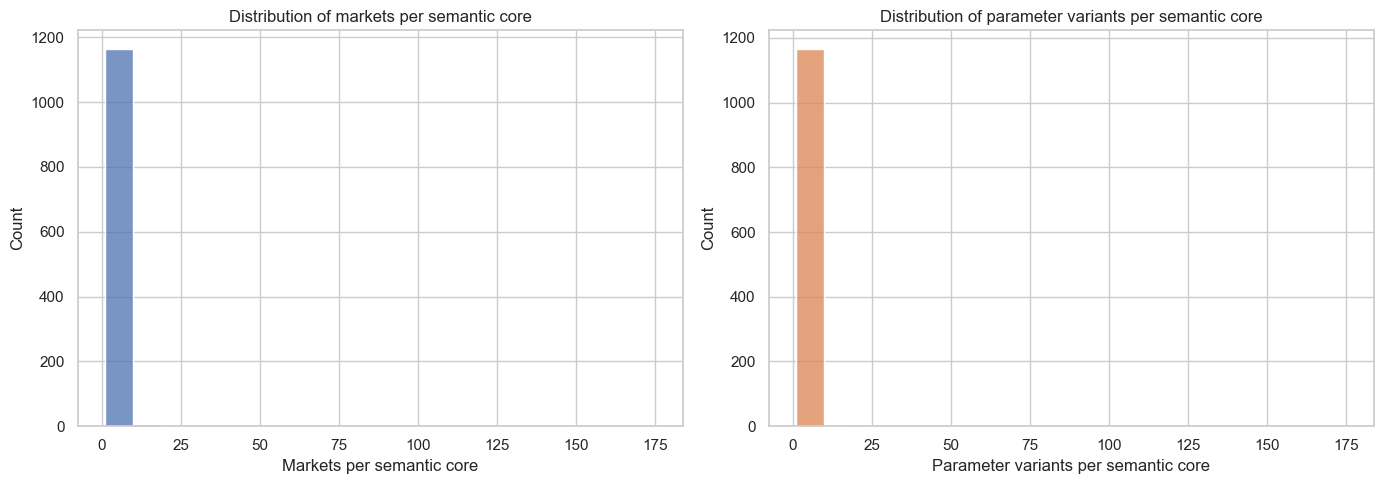

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(core_stats['market_count'], bins=20, ax=axes[0], color='#4c72b0')
axes[0].set_title('Distribution of markets per semantic core')
axes[0].set_xlabel('Markets per semantic core')

sns.histplot(core_stats['parameter_count'], bins=20, ax=axes[1], color='#dd8452')
axes[1].set_title('Distribution of parameter variants per semantic core')
axes[1].set_xlabel('Parameter variants per semantic core')

plt.tight_layout()
plt.show()

## Строим простые embeddings

Пока не учим отдельную text model. Вместо этого сравним несколько дешёвых представлений:

- TF-IDF по полной формулировке вопроса;
- TF-IDF по semantic core;
- semantic core + tag overlap.

Этого достаточно, чтобы проверить, помогает ли decomposition улучшать retrieval близких вопросов.

In [8]:
question_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
core_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)

question_matrix = question_vectorizer.fit_transform(markets['question_norm'])
core_matrix = core_vectorizer.fit_transform(markets['semantic_core'])

question_similarity = cosine_similarity(question_matrix)
core_similarity = cosine_similarity(core_matrix)

tag_similarity = np.zeros((len(markets), len(markets)))
for i, left_tags in enumerate(markets['tag_labels']):
    for j, right_tags in enumerate(markets['tag_labels']):
        tag_similarity[i, j] = tag_jaccard(left_tags, right_tags)

semantic_plus_tags_similarity = 0.85 * core_similarity + 0.15 * tag_similarity

np.fill_diagonal(question_similarity, -1)
np.fill_diagonal(core_similarity, -1)
np.fill_diagonal(semantic_plus_tags_similarity, -1)

print(question_matrix.shape, core_matrix.shape)

(1921, 2442) (1921, 1834)


## Как будем оценивать closeness

Нам нужны две разные positive relation:

- **same semantic core**: один и тот же базовый event template;
- **same semantic core, different parameterization**: более интересный режим для идеи `6`, где рынки похожи по сути, но отличаются числами или дедлайнами.

Если semantic-core embedding работает лучше full-question embedding именно на втором режиме, это хороший признак, что decomposition полезна.

In [9]:
same_core = markets['semantic_core'].to_numpy()[:, None] == markets['semantic_core'].to_numpy()[None, :]
same_parameter = markets['parameter_signature'].to_numpy()[:, None] == markets['parameter_signature'].to_numpy()[None, :]
same_family = markets['family_id'].to_numpy()[:, None] == markets['family_id'].to_numpy()[None, :]
np.fill_diagonal(same_core, False)
np.fill_diagonal(same_parameter, False)
np.fill_diagonal(same_family, False)

same_core_diff_param = same_core & (~same_parameter)

def recall_at_k(similarity: np.ndarray, positives: np.ndarray, k: int = 5) -> float:
    """Compute mean recall@k over rows that have at least one positive."""
    scores = []
    for i in range(similarity.shape[0]):
        positive_idx = np.flatnonzero(positives[i])
        if len(positive_idx) == 0:
            continue
        top_idx = np.argsort(similarity[i])[::-1][:k]
        scores.append(np.isin(positive_idx, top_idx).sum() / len(positive_idx))
    return float(np.mean(scores)) if scores else np.nan

def hit_rate_at_k(similarity: np.ndarray, positives: np.ndarray, k: int = 5) -> float:
    """Compute whether at least one positive appears in top-k."""
    scores = []
    for i in range(similarity.shape[0]):
        positive_idx = np.flatnonzero(positives[i])
        if len(positive_idx) == 0:
            continue
        top_idx = np.argsort(similarity[i])[::-1][:k]
        scores.append(float(np.isin(top_idx, positive_idx).any()))
    return float(np.mean(scores)) if scores else np.nan


## Retrieval metrics for different embeddings

Это центральная сравнительная таблица notebook. Она показывает, какая форма вопросного представления лучше находит близкие рынки. Самые важные колонки:

- `same_core_recall@5`: находит ли embedding рынки с тем же semantic core;
- `same_core_diff_param_recall@5`: особенно важный режим для идеи `6`;
- `same_family_hit@5`: насколько embedding согласован с текущей weak family structure.

In [10]:
metric_rows = []
for name, sim in [
    ('full_question', question_similarity),
    ('semantic_core', core_similarity),
    ('semantic_core_plus_tags', semantic_plus_tags_similarity),
]:
    metric_rows.append({
        'representation': name,
        'same_core_recall@5': recall_at_k(sim, same_core, TOP_K),
        'same_core_hit@5': hit_rate_at_k(sim, same_core, TOP_K),
        'same_core_diff_param_recall@5': recall_at_k(sim, same_core_diff_param, TOP_K),
        'same_core_diff_param_hit@5': hit_rate_at_k(sim, same_core_diff_param, TOP_K),
        'same_family_hit@5': hit_rate_at_k(sim, same_family, TOP_K),
    })
metrics_table = pd.DataFrame(metric_rows).sort_values('same_core_diff_param_recall@5', ascending=False)
display(metrics_table)

,representation,same_core_recall@5,same_core_hit@5,same_core_diff_param_recall@5,same_core_diff_param_hit@5,same_family_hit@5
2,semantic_core_plus_tags,0.629228,1.000000,0.625563,1.00000,0.652977
1,semantic_core,0.629228,1.000000,0.625240,1.00000,0.620123
0,full_question,0.577325,0.995628,0.572303,0.99558,0.967146


## График по самой важной retrieval-метрике

Для идеи `6` особенно важен режим `same semantic core, different parameterization`. Именно он показывает, умеет ли представление отделять суть вопроса от числовой модификации.

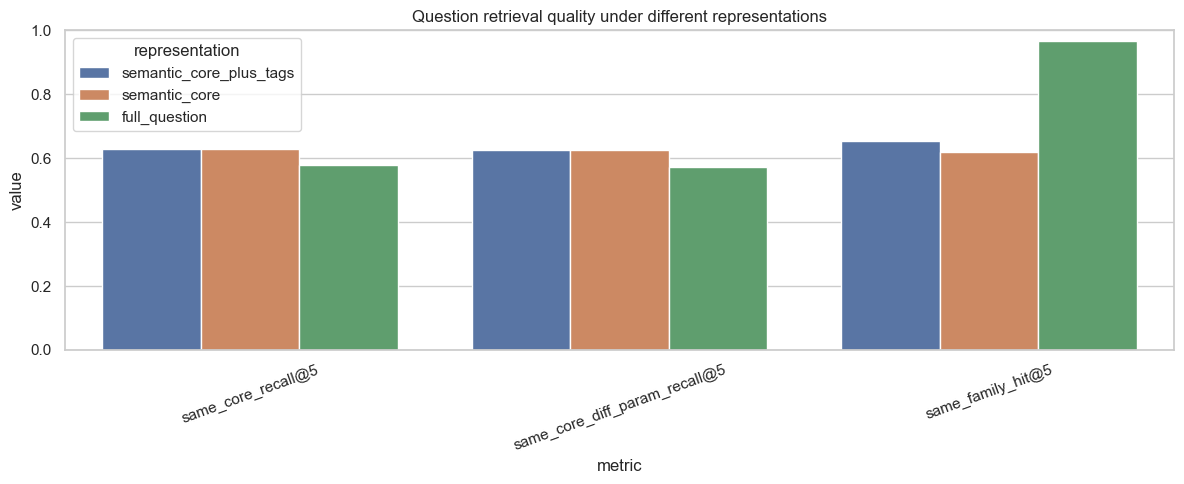

In [11]:
plot_table = metrics_table.melt(
    id_vars='representation',
    value_vars=['same_core_recall@5', 'same_core_diff_param_recall@5', 'same_family_hit@5'],
    var_name='metric',
    value_name='value',
)
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_table, x='metric', y='value', hue='representation')
plt.title('Question retrieval quality under different representations')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Примеры nearest neighbors

Теперь посмотрим не только на aggregate metrics, но и на конкретные query examples. Это помогает увидеть, где full-question retrieval путается из-за чисел, а semantic-core retrieval находит более правильных соседей.

In [12]:
def nearest_neighbors(query_idx: int, similarity: np.ndarray, top_k: int = 5) -> pd.DataFrame:
    """Return the top-k nearest neighbors for a query market under a similarity matrix."""
    top_idx = np.argsort(similarity[query_idx])[::-1][:top_k]
    frame = markets.iloc[top_idx][['question', 'semantic_core', 'parameter_signature', 'primary_domain']].copy()
    frame.insert(0, 'similarity', similarity[query_idx][top_idx])
    return frame.reset_index(drop=True)

candidate_queries = markets.loc[markets['semantic_core'].isin(parameterized_groups.head(20)['semantic_core'])].copy()
query_rows = candidate_queries.sample(min(3, len(candidate_queries)), random_state=RANDOM_STATE)
for idx, row in query_rows.iterrows():
    print('=' * 140)
    print('QUERY:', row['question'])
    print('semantic_core:', row['semantic_core'])
    print('parameter_signature:', row['parameter_signature'])
    print('\nFull-question neighbors')
    display(nearest_neighbors(idx, question_similarity, top_k=TOP_K))
    print('Semantic-core neighbors')
    display(nearest_neighbors(idx, core_similarity, top_k=TOP_K))


QUERY: Israel strikes Iran by January 16, 2026?
semantic_core: israel strikes iran
parameter_signature: january 16 2026 | 2026 | 16

Full-question neighbors


,similarity,question,semantic_core,parameter_signature,primary_domain
0,0.815669,"US strikes Iran by January 16, 2026?",us strikes iran,january 16 2026 | 2026 | 16,geopolitics
1,0.759264,"Israel strikes Iran by January 9, 2026?",israel strikes iran,january 9 2026 | 2026 | 9,geopolitics
2,0.690159,"Israel strikes Iran by January 31, 2026?",israel strikes iran,january 31 2026 | 2026 | 31,geopolitics
3,0.644129,"Israel strikes Iran by January 23, 2026?",israel strikes iran,january 23 2026 | 2026 | 23,geopolitics
4,0.567221,"Israel strikes Iran by March 31, 2026?",israel strikes iran,march 31 2026 | 2026 | 31,geopolitics


Semantic-core neighbors


,similarity,question,semantic_core,parameter_signature,primary_domain
0,1.0,"Israel strikes Iran by January 23, 2026?",israel strikes iran,january 23 2026 | 2026 | 23,geopolitics
1,1.0,Israel strikes Iran by October 31?,israel strikes iran,october 31 | 31,geopolitics
2,1.0,"Israel strikes Iran by January 31, 2026?",israel strikes iran,january 31 2026 | 2026 | 31,geopolitics
3,1.0,Israel strikes Iran before 2026?,israel strikes iran,2026,geopolitics
4,1.0,"Israel strikes Iran by January 9, 2026?",israel strikes iran,january 9 2026 | 2026 | 9,geopolitics


QUERY: Will Elon Musk post 420-439 tweets from December 30 to January 6, 2026?
semantic_core: will elon musk post tweets from to
parameter_signature: december 30 | january 6 2026 | 2026 | 420 | 439 | 30 | 6

Full-question neighbors


...

,similarity,question,semantic_core,parameter_signature,primary_domain
0,1.0,"Will Elon Musk post 200-219 tweets from November 18 to November 25, 2025?",will elon musk post tweets from to,november 18 | november 25 2025 | 2025 | 200 | 219 | 18 | 25,politics
1,1.0,"Will Elon Musk post 340-359 tweets from January 27 to February 3, 2026?",will elon musk post tweets from to,january 27 | february 3 2026 | 2026 | 340 | 359 | 27 | 3,politics
2,1.0,"Will Elon Musk post 520-539 tweets from January 13 to January 20, 2026?",will elon musk post tweets from to,january 13 | january 20 2026 | 2026 | 520 | 539 | 13 | 20,politics
3,1.0,"Will Elon Musk post 400-419 tweets from January 20 to January 27, 2026?",will elon musk post tweets from to,january 20 | january 27 2026 | 2026 | 400 | 419 | 20 | 27,politics
4,1.0,"Will Elon Musk post 220-239 tweets from November 25 to December 2, 2025?",will elon musk post tweets from to,november 25 | december 2 2025 | 2025 | 220 | 239 | 25 | 2,politics


QUERY: Will NVIDIA be the largest company in the world by market cap on July 31?
semantic_core: will nvidia be the largest company in the world market cap on
parameter_signature: july 31 | 31

Full-question neighbors


,similarity,question,semantic_core,parameter_signature,primary_domain
0,0.852175,Will NVIDIA be the largest company in the world by market cap on March 31?,will nvidia be the largest company in the world market cap on,march 31 | 31,technology
1,0.848943,Will NVIDIA be the largest company in the world by market cap on January 31?,will nvidia be the largest company in the world market cap on,january 31 | 31,technology
2,0.822949,Will NVIDIA be the largest company in the world by market cap on February 28?,will nvidia be the largest company in the world market cap on,february 28 | 28,technology
3,0.822949,Will NVIDIA be the largest company in the world by market cap on February 28?,will nvidia be the largest company in the world market cap on,february 28 | 28,technology
4,0.822249,Will NVIDIA be the largest company in the world by market cap on August 31?,will nvidia be the largest company in the world market cap on,august 31 | 31,technology


Semantic-core neighbors


,similarity,question,semantic_core,parameter_signature,primary_domain
0,1.0,Will NVIDIA be the largest company in the world by market cap on June 30?,will nvidia be the largest company in the world market cap on,june 30 | 30,technology
1,1.0,Will NVIDIA be the largest company in the world by market cap on September 30?,will nvidia be the largest company in the world market cap on,september 30 | 30,technology
2,1.0,Will NVIDIA be the largest company in the world by market cap on March 31?,will nvidia be the largest company in the world market cap on,march 31 | 31,technology
3,1.0,Will NVIDIA be the largest company in the world by market cap on November 30?,will nvidia be the largest company in the world market cap on,november 30 | 30,technology
4,1.0,Will NVIDIA be the largest company in the world by market cap on May 31?,will nvidia be the largest company in the world market cap on,may 31 | 31,technology


## Что это значит для идеи 6

Если semantic-core representation стабильно лучше находит рынки с тем же базовым событием, но другой parameterization, это поддерживает следующую архитектурную идею:

- question encoder should not rely on a single raw text embedding;
- it should decompose the question into semantic core and parameterization;
- masked market reconstruction can then condition on both parts separately.

Практически это даёт два ближайших применения:

- better duplicate / near-duplicate control in benchmark design;
- better retrieval of related markets for hidden-market reconstruction.